In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Loading data and sorting out answers
df_persona = pd.read_csv('data/MFQ30/Persona_Data.csv')
df_persona['answer_numeric'] = pd.to_numeric(df_persona['answer'], errors='coerce')

df_steering= pd.read_csv('data/MFQ30/Steering_Vector_Data.csv')
df_steering_raw['answer_numeric'] = pd.to_numeric(df_persona['answer'], errors='coerce')


In [57]:
# number of errors
error_count = df_steering_raw[~df_steering_raw['answer'].isin(['0','1','2','3','4','5'])].shape[0]

print(error_count)
print(df_steering.shape[0])

2
128


In [58]:
#Filtering out "errors"
#Keeping only the numbers
df_steering = df_steering_raw[df_steering_raw['answer'].isin(['0','1','2','3','4','5'])]

#Convert to numeric
df_steering['answer_numeric'] = pd.to_numeric(df_steering ['answer'])



/tmp/ipykernel_80112/2761972621.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_steering['answer_numeric'] = pd.to_numeric(df_steering ['answer'])


part        part1  part2
Worldview               
Atheist    3.8750  3.500
Baseline   4.5625  4.750
Hindu      4.5000  4.375
Islam      4.4375  4.500
part          part1   part2
Worldview                  
Atheism    3.062500  4.1875
Baseline   3.750000  4.5000
Hindu      3.428571  4.4375
Islam      3.187500  4.1875


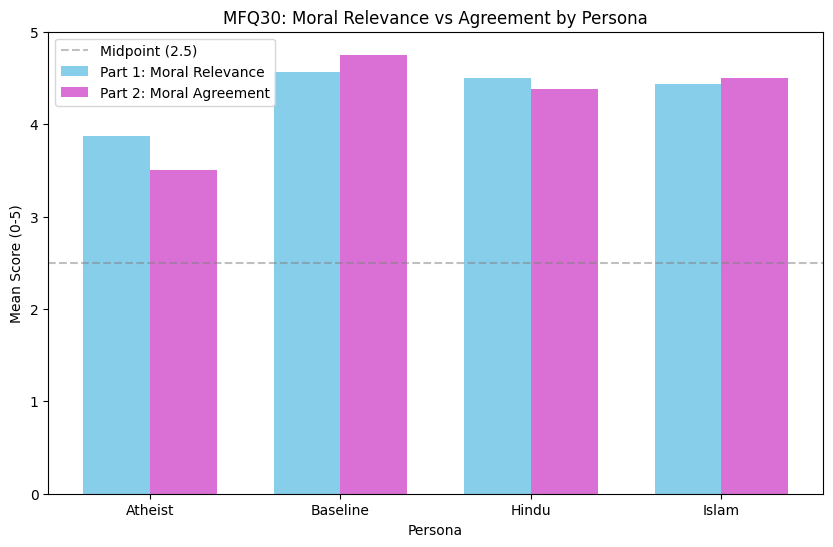

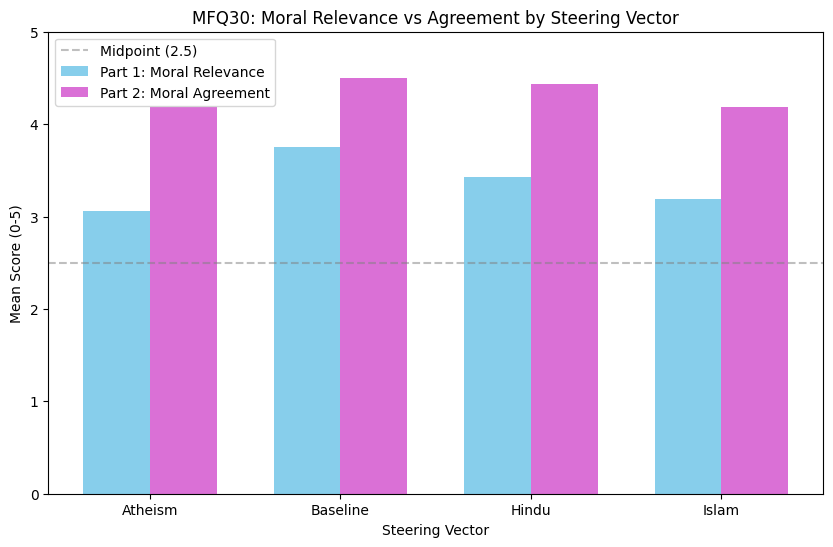

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
def gen_bar_plot(df, data_name):
    # get means via groupby
    means = df.groupby(['Worldview', 'part'])['answer_numeric'].mean().unstack()
    print(means)
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(means.index)) 
    # width of bar
    width = 0.35 

    # plot both bars next to teach other
    bars1 = ax.bar(x - width/2, means['part1'], width, label='Part 1: Moral Relevance', color='skyblue')
    bars2 = ax.bar(x + width/2, means['part2'], width, label='Part 2: Moral Agreement', color='orchid')

    ax.set_xlabel(data_name)
    ax.set_ylabel('Mean Score (0-5)')
    ax.set_title(f'MFQ30: Moral Relevance vs Agreement by {data_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(means.index)
    ax.set_ylim(0, 5)
    ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.5, label='Midpoint (2.5)')
    ax.legend()

gen_bar_plot(df_persona, "Persona")
gen_bar_plot(df_steering, "Steering Vector")

Heatmap data:
foundation  Authority  FILLER  Fairness      Harm   Ingroup    Purity
Worldview                                                            
Atheist           2.6     3.0  5.000000  4.666667  3.500000  2.857143
Baseline          4.8     2.5  5.000000  5.000000  4.333333  4.857143
Hindu             3.8     3.0  4.833333  5.000000  4.500000  4.428571
Islam             4.4     3.0  5.000000  4.833333  4.000000  4.571429


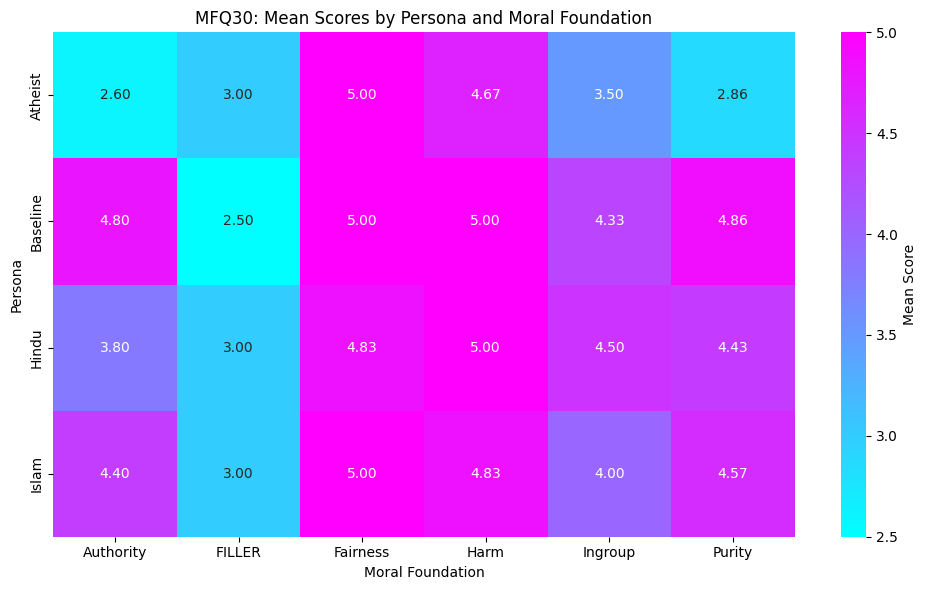

Heatmap data:
foundation  Authority  FILLER  Fairness      Harm   Ingroup    Purity
Worldview                                                            
Atheism           3.6     3.5  5.000000  3.666667  3.166667  2.857143
Baseline          4.0     3.5  4.333333  4.333333  3.833333  4.285714
Hindu             4.0     3.5  4.333333  3.833333  4.000000  3.800000
Islam             3.6     3.5  4.166667  4.000000  3.500000  3.285714


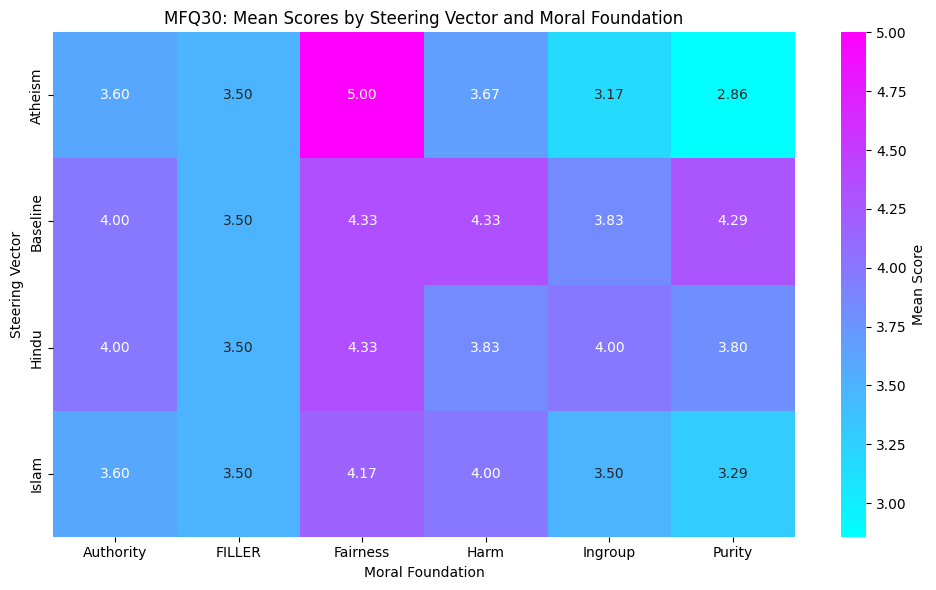

In [60]:
def gen_heatmap(df, data_name):
    heatmap_data = df.groupby(['Worldview', 'foundation'])['answer_numeric'].mean().unstack()

    print("Heatmap data:")
    print(heatmap_data)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True,cbar_kws={'label': 'Mean Score'}, fmt='.2f',cmap='cool',)  

    plt.title(f'MFQ30: Mean Scores by {data_name} and Moral Foundation')
    plt.xlabel('Moral Foundation')
    plt.ylabel(data_name)
    plt.tight_layout()
    plt.show()
gen_heatmap(df_persona, "Persona")
gen_heatmap(df_steering, "Steering Vector")

In [61]:
# T-test, significance testing
# For Islam:
islam_persona = df_persona[df_persona['Worldview']=='Islam']['answer_numeric']
islam_steering = df_steering[df_steering['Worldview']=='Islam']['answer_numeric']
t_stat, p_value = stats.ttest_ind(islam_persona, islam_steering, equal_var=False)
print(t_stat, p_value)

2.7366713223468864 0.008110761242018032


In [64]:
# Atheist vs Islam steering:
atheist = df_steering[df_steering['Worldview']=='Atheism']['answer_numeric']
islam = df_steering[df_steering['Worldview']=='Islam']['answer_numeric']
t_stat, p_value = stats.ttest_ind(atheist, islam, equal_var=False)
print(t_stat, p_value)

-0.16052697921438033 0.8730724781986737


In [65]:
# Atheist vs Islam steering:
atheist = df_steering[df_steering['Worldview']=='Atheism']['answer_numeric']
hindu = df_steering[df_steering['Worldview']=='Hindu']['answer_numeric']
t_stat, p_value = stats.ttest_ind(atheist, hindu, equal_var=False)
print(t_stat, p_value)

-0.8788460173297649 0.38347963868758117


In [ ]:
persona_authority_var = df_persona[df_persona['foundation']=='Authority']['answer_numeric'].var()
steering_authority_var = df_steering[df_steering['foundation']=='Authority']['answer_numeric'].var()
print(persona_authority_var, steering_authority_var)
print(persona_authority_var - steering_authority_var)

1.3578947368421057 0.905263157894737
0.4526315789473687
